In [2]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.ensemble import RandomForestRegressor

pd.set_option('display.max_columns', None)

### Подготовка данных

In [13]:
# Чтение файла с тегами.
df = pd.read_excel(r'E:\Projects\portfolio\ad_creative_performance_analyzer\materials\tagging.xlsx')

In [14]:
# Колонки, которые не нужно учитывать
cols_drop = ['adtext_text','adtext_eng','headline_text','headline_eng','description_text','image_text',
             'image_eng_text','image_clip','image_clip_keywords']

df_work = df.copy()

# Очистка от сырых текстов и системных полей ---
cols_to_drop = [col for col in cols_drop if col in df_work.columns]
df_work = df_work.drop(columns = cols_drop)

### Поиск колонок с массивами

In [15]:
# Поиск множественных строк (псевдо списков) и перевод их в реальные списки
def is_text_array(val):
    # Функция, которая проверяет, является ли текст замаскированным списком
    if isinstance(val, str) and val.startswith('[') and val.endswith(']'):
        try:
            # Пробуем безопасно прочитать структуру текста
            parsed = ast.literal_eval(val)
            return isinstance(parsed, list)
        except (ValueError, SyntaxError):
            return False
    return False

# Ищем все колонки, где есть такие текстовые списки
text_array_cols = [
    col for col in df_work.columns 
    if df_work[col].dropna().apply(is_text_array).any()
    ]

# Переводим их в настоящие списки Python
for col in text_array_cols:
    # Безопасно превращаем строки "['a', 'b']" в реальные списки Python ['a', 'b']
    df_work[col] = df_work[col].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') 
        else ([] if not isinstance(x, list) else x)
    )

print(text_array_cols)

['adtext_nouns', 'adtext_verbs', 'adtext_adjs', 'headline_nouns', 'headline_verbs', 'headline_adjs', 'description_nouns', 'description_verbs', 'description_adjs', 'image_nouns', 'image_verbs', 'image_adjs', 'image_phrases', 'image_color_rest', 'image_objects', 'image_tags']


### Поиск категориальных колонок

In [16]:
# Отбираем все колонки с типом данных object или category
potential_cat_cols = df_work.select_dtypes(include=['object', 'category']).columns

# Исключаем из них те, которые уже сохранены в text_array_cols
categorical_cols = [col for col in potential_cat_cols if col not in text_array_cols]

print(categorical_cols)

['adtext_language', 'headline_language', 'cta_type', 'image_language', 'image_color_main', 'image_proportions']


### One-Hot Encoding (прямое кодирование): 
`MultiLabelBinarizer` сканирует все списки в колонке (например, `image_objects`), собирает словарь всех уникальных объектов и создает под каждый объект отдельную колонку с нулями.  
Если в текущей строке объект есть — ставит `1`.

In [17]:
# Адаптация под размер выборки
n_samples = len(df_work)
min_freq = 1 if n_samples < 30 else 3

# Словарь для маппинга созданных колонок к родительской группе
feature_groups = {}

for col in list(text_array_cols):
    mlb = MultiLabelBinarizer()
    binary_matrix = mlb.fit_transform(df_work[col])
    
    # Отсеиваем слишком редкие значения
    class_counts = binary_matrix.sum(axis=0)
    valid_classes_idx = [i for i, count in enumerate(class_counts) if count >= min_freq]
    
    valid_classes = [mlb.classes_[i] for i in valid_classes_idx]
    valid_matrix = binary_matrix[:, valid_classes_idx]
    
    col_names = [f"{col}_{cls}" for cls in valid_classes]
    df_bin = pd.DataFrame(valid_matrix, columns=col_names, index=df_work.index)
    
    # Привязываем бинарные колонки к исходной группе
    for cn in col_names:
        feature_groups[cn] = col
        
    df_work = pd.concat([df_work, df_bin], axis=1)
    df_work = df_work.drop(columns=[col])

In [18]:
# Обычные категориальные признаки
cat_cols = [col for col in categorical_cols if col in df_work.columns]

for col in cat_cols:
    dummies = pd.get_dummies(df_work[col], prefix=col)
    for cn in dummies.columns:
        feature_groups[cn] = col
    df_work = pd.concat([df_work, dummies], axis=1)
    df_work = df_work.drop(columns=[col])

# Булевы колонки в int
bool_cols = df_work.select_dtypes(include=['bool']).columns
df_work[bool_cols] = df_work[bool_cols].astype(int)

# Связываем остальные незатронутые фичи (например, длины текстов)
for col in df_work.columns:
    if col not in feature_groups and col != 'ctr':
        feature_groups[col] = col

In [ ]:
# Удаление колонок где вообще нет значений (Null)
df_work = df_work.dropna(axis=1, how='all')
df_work.head()

,adtext_length,adtext_contains_cta,adtext_contains_question,headline_length,headline_contains_cta,headline_contains_question,description_length,description_contains_cta,description_contains_question,image_text_present,image_text_area,image_text_length,image_text_contains_question,image_text_contains_cta,image_people_amount,ctr,adtext_nouns_affirmations,adtext_nouns_app,adtext_nouns_articles,adtext_nouns_astrology,adtext_nouns_blueprint,adtext_nouns_calendar,adtext_nouns_charts,adtext_nouns_cycles,adtext_nouns_destiny,adtext_nouns_esoterics,adtext_nouns_horizon,adtext_nouns_horoscopes,adtext_nouns_journey,adtext_nouns_kind,adtext_nouns_lifes,adtext_nouns_lot,adtext_nouns_moon,adtext_nouns_natal,adtext_nouns_nature,adtext_nouns_personality,adtext_nouns_phases,adtext_nouns_rituals,adtext_nouns_runes,adtext_nouns_secrets,adtext_nouns_skin,adtext_nouns_spirituality,adtext_nouns_step,adtext_nouns_sunshine,adtext_nouns_thing,adtext_nouns_universe,adtext_nouns_wisdom,adtext_nouns_wisdoms,adtext_verbs_contains,adtext_verbs_defines,adtext_verbs_discover,adtext_verbs_do,adtext_verbs_enjoy,adtext_verbs_expands,adtext_verbs_feel,adtext_verbs_follow,adtext_verbs_harmonize,adtext_verbs_have,adtext_verbs_introducing,adtext_verbs_know,adtext_verbs_learn,adtext_verbs_love,adtext_verbs_receive,adtext_verbs_take,adtext_verbs_uncover,adtext_verbs_wanted,adtext_adjs_ancient,adtext_adjs_cosmic,adtext_adjs_daily,adtext_adjs_different,adtext_adjs_favorite,adtext_adjs_female,adtext_adjs_first,adtext_adjs_moonly,adtext_adjs_only,adtext_adjs_personalized,adtext_adjs_positive,adtext_adjs_sacred,adtext_adjs_unique,headline_nouns_birth,headline_nouns_calendar,headline_nouns_chart,headline_nouns_cycle,headline_nouns_magic,headline_nouns_moon,headline_nouns_pocket,headline_nouns_self,headline_verbs_decode,headline_verbs_get,headline_verbs_try,headline_verbs_unveil,headline_adjs_happiest,headline_adjs_true,image_nouns_abilities,image_nouns_ability,image_nouns_acorns,image_nouns_acquaintances,image_nouns_action,image_nouns_actions,image_nouns_activities,image_nouns_activity,image_nouns_affirmations,image_nouns_age,image_nouns_altar,image_nouns_anxiety,image_nouns_apple,image_nouns_astrology,image_nouns_attachments,image_nouns_attention,image_nouns_beaver,image_nouns_birth,image_nouns_birthday,image_nouns_blueprint,image_nouns_c,image_nouns_calendar,image_nouns_candle,image_nouns_candles,image_nouns_card,image_nouns_care,image_nouns_center,image_nouns_challenge,image_nouns_character,image_nouns_charge,image_nouns_charity,image_nouns_chart,image_nouns_cider,image_nouns_cl,image_nouns_co,image_nouns_coffee,image_nouns_communication,image_nouns_control,image_nouns_core,image_nouns_craving,image_nouns_creativity,image_nouns_crystals,image_nouns_curiosity,image_nouns_cycle,image_nouns_cycles,image_nouns_day,image_nouns_days,image_nouns_decisions,image_nouns_deeds,image_nouns_deer,image_nouns_distrust,image_nouns_education,image_nouns_emotions,image_nouns_energy,image_nouns_enhances,image_nouns_fear,image_nouns_flower,image_nouns_fn,image_nouns_fr,image_nouns_friends,image_nouns_fruit,image_nouns_future,image_nouns_gemini,image_nouns_good,image_nouns_gratitude,image_nouns_guide,image_nouns_guilt,image_nouns_h,image_nouns_harvest,image_nouns_heart,image_nouns_help,image_nouns_hints,image_nouns_hobby,image_nouns_holidays,image_nouns_home,image_nouns_house,image_nouns_hunters,image_nouns_illusions,image_nouns_incense,image_nouns_intention,image_nouns_intuition,image_nouns_j,image_nouns_jupiter,image_nouns_knowledge,image_nouns_leadership,image_nouns_learning,image_nouns_leaves,image_nouns_leisure,image_nouns_lies,image_nouns_life,image_nouns_list,image_nouns_love,image_nouns_m,image_nouns_mabon,image_nouns_manifestations,image_nouns_mantras,image_nouns_mars,image_nouns_meditate,image_nouns_meditations,image_nouns_mercury,image_nouns_mindset,image_nouns_minutes,image_nouns_mood,image_nouns_moon,image_nouns_moons,image_nouns_morning,image_nouns_natal,image_nouns_nature,ima

### Обучение модели Random Forest

In [20]:
X = df_work.drop(columns=['ctr'])
y = df_work['ctr']

rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=5 if n_samples < 30 else None, 
    random_state=42
)
rf.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Расчет важности признаков

In [22]:
importances = rf.feature_importances_
feature_imp_df = pd.DataFrame({'feature_col': X.columns, 'importance': importances})
feature_imp_df['group'] = feature_imp_df['feature_col'].map(feature_groups)

grouped_imp = feature_imp_df.groupby('group')['importance'].sum().reset_index()
grouped_imp['importance_pct'] = (grouped_imp['importance'] / grouped_imp['importance'].sum()) * 100
grouped_imp = grouped_imp.sort_values(by='importance_pct', ascending=False).reset_index(drop=True)

grouped_imp

,group,importance,importance_pct
0,image_text_length,0.192255,19.225486
1,image_nouns,0.175921,17.592092
2,image_verbs,0.173129,17.312943
3,image_phrases,0.160793,16.079292
4,image_proportions,0.079595,7.959545
5,image_tags,0.075057,7.505651
6,image_adjs,0.026134,2.613365
7,headline_nouns,0.022218,2.221830
8,image_color_rest,0.017674,1.767373
9,image_color_main,0.015803,1.580341


### Визуализация

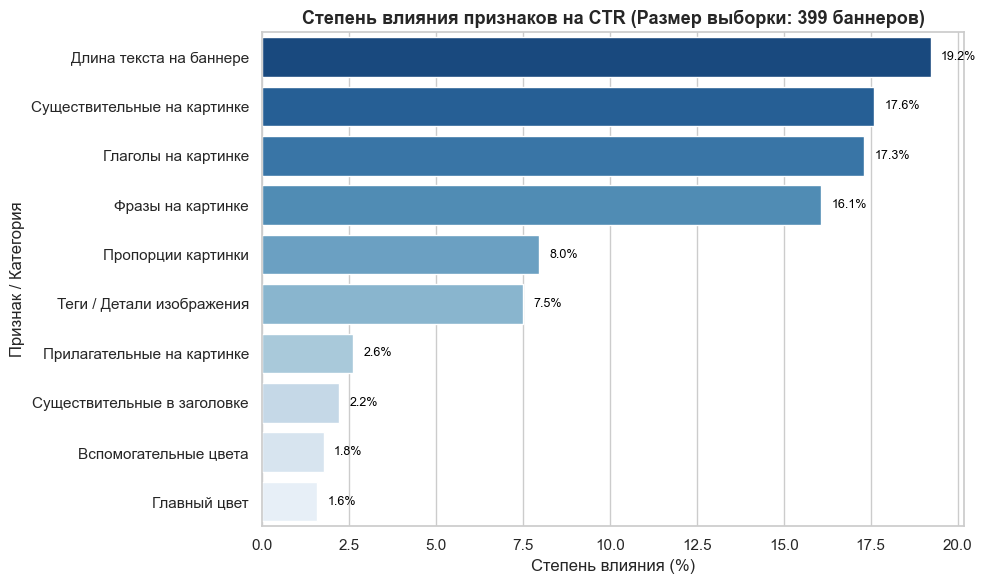

In [ ]:
plot=True
top_n = 10

# --- 5. Построение графика ---
if plot:
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    top_df = grouped_imp.head(top_n).copy()
    
    # Понятные названия категорий
    name_map = {
        'image_phrases': 'Фразы на картинке',
        'image_text_length': 'Длина текста на баннере',
        'image_verbs': 'Глаголы на картинке',
        'image_nouns': 'Существительные на картинке',
        'image_tags': 'Теги / Детали изображения',
        'image_proportions': 'Пропорции картинки',
        'image_adjs': 'Прилагательные на картинке',
        'headline_nouns': 'Существительные в заголовке',
        'image_color_main': 'Главный цвет',
        'adtext_nouns': 'Существительные в тексте',
        'image_objects': 'Объекты на картинке',
        'image_color_rest': 'Вспомогательные цвета',
        'image_people_amount': 'Кол-во людей на картинке',
        'image_text_area': 'Объем текста на картинке'
    }
    top_df['readable_name'] = top_df['group'].map(lambda x: name_map.get(x, x))
    
    ax = sns.barplot(x='importance_pct', 
                     y='readable_name', 
                     data=top_df, 
                     palette='Blues_r',
                     hue='readable_name')
    plt.title(f'Степень влияния признаков на CTR (Размер выборки: {n_samples} баннеров)', fontsize=13, fontweight='bold')
    plt.xlabel('Степень влияния (%)')
    plt.ylabel('Признак / Категория')
    
    # Добавляем проценты на график
    for p in ax.patches:
        w = p.get_width()
        ax.annotate(f'{w:.1f}%', (w + 0.3, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=9, color='black')
                    
    plt.tight_layout()
    plt.show()